# Cards retrieval from MUL

In [40]:
# @title
print("LOADING ANCIENT SCRIPTS")

LOADING ANCIENT SCRIPTS


In [41]:
# @title
%%capture
!python -m pip install jupyter-ui-poll
from ipywidgets import Button
from jupyter_ui_poll import ui_events
!python -m pip install fpdf2
import requests
import urllib.parse
import time
import os
from datetime import datetime
from IPython.display import Image, display
from fpdf import FPDF

In [42]:
# @title
print("ANCIENT SCRIPTS READY")

ANCIENT SCRIPTS READY


In [43]:
# @title
editor = widgets.Textarea(
    value=СПИСОК_МЕХОВ,
    placeholder='Вставьте список юнитов...',
    layout={'width': '100%', 'height': '400px'},
    spellcheck=False
)

top_m = widgets.IntText(
    value=6,
    description='ОТСТУП_СВЕРХУ:',
    style={'description_width': 'initial'}
)

left_m = widgets.IntText(
    value=6,
    description='ОТСТУП_СЛЕВА:',
    style={'description_width': 'initial'}
)
button = widgets.Button(description="СОХРАНИТЬ И ПРОДОЛЖИТЬ", button_style='danger', layout={'width': '100%'})
output = widgets.Output()

display(editor, widgets.HBox([top_m, left_m]), button, output)

clicked = False
def on_button_clicked(b):
    global clicked
    clicked = True

button.on_click(on_button_clicked)

with ui_events() as poll:
    while not clicked:
        poll(10)
        time.sleep(0.1)

СПИСОК_МЕХОВ = editor.value
ОТСТУП_СВЕРХУ = top_m.value
ОТСТУП_СЛЕВА = left_m.value

with output:
    clear_output()
    print("NEXT")


Textarea(value="'Игрок 1, '\n'Mad Cat (Timber Wolf) A^2, '\n'Mad Cat (Timber Wolf) A^2, '\n'Marauder IIC  ^2, …

Button(button_style='danger', description='СОХРАНИТЬ И ПРОДОЛЖИТЬ', layout=Layout(width='100%'), style=ButtonS…

Output()

Connect and get confirmation of connection

In [44]:
# @title

base_url = "https://masterunitlist.azurewebsites.net/Unit/QuickList?Name="

urls = []
skills = []

raw_items = [item.strip() for item in СПИСОК_МЕХОВ.replace("'","").split(',') if item.strip()]

for item in raw_items:
    if '^' in item:
        parts = item.split('^')
        name = parts[0].strip()

        skill = parts[-1].strip()

    else:
        name = item.strip()
        skill = ""

    if "Игрок" in name:
      url = name
      print(name)
    else:
      url = base_url + name.replace(' ', '%20')
      print(url + " SKILL: " + skill)

    urls.append(url)
    skills.append(skill)

Игрок 1
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Mad%20Cat%20(Timber%20Wolf)%20A SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Mad%20Cat%20(Timber%20Wolf)%20A SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Marauder%20IIC SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=BattleMaster%20BLR-1G%20(Red%20Corsair) SKILL: 1
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Loki%20(Hellbringer)%20A SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Grizzly SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Uller%20(Kit%20Fox)%20H SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Pouncer%20D SKILL: 1
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Ryoken%20(Stormcrow)%20E SKILL: 1
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Koshi%20(Mist%20Lynx)%20H SKILL: 2
https://masterunitlist.azurewebsites.net/Unit/QuickLi

In [45]:
# @title
unit_ids = list()
cache = {}

for url in urls:

    if url in cache:
        unit_id = cache[url]
        unit_ids.append(unit_id)
        print(f"{url} Repeat ID {unit_id}")
        continue

    if "Игрок" in url:
      unit_ids.append(url)
      print(f"{url}")
      continue
    else:
      url = url.replace(' ', '%20')
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        if data.get("Units"):
            unit_id = data["Units"][0]["Id"]

            cache[url] = unit_id
            unit_ids.append(unit_id)
            print(f"{url} ID {unit_id}")
        else:
            print(f"{url} NOT FOUND")
            cache[url] = None

    except Exception as e:
          print(f"ERROR {url}: {e}")

    time.sleep(0.1)

print(unit_ids)

Игрок 1
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Mad%20Cat%20(Timber%20Wolf)%20A ID 1978
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Mad%20Cat%20(Timber%20Wolf)%20A Repeat ID 1978
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Marauder%20IIC ID 2066
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=BattleMaster%20BLR-1G%20(Red%20Corsair) ID 284
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Loki%20(Hellbringer)%20A ID 1923
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Grizzly ID 1333
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Uller%20(Kit%20Fox)%20H ID 3346
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Pouncer%20D ID 2560
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Ryoken%20(Stormcrow)%20E ID 2753
https://masterunitlist.azurewebsites.net/Unit/QuickList?Name=Koshi%20(Mist%20Lynx)%20H ID 1834
https://masterunitlist.azurewebsites.net/Unit/QuickList?N

Make a list of mech cards

Игрок 1
URL: http://masterunitlist.info/Unit/Card/1978?skill=2
SAVED: units_cards/card_1978.png


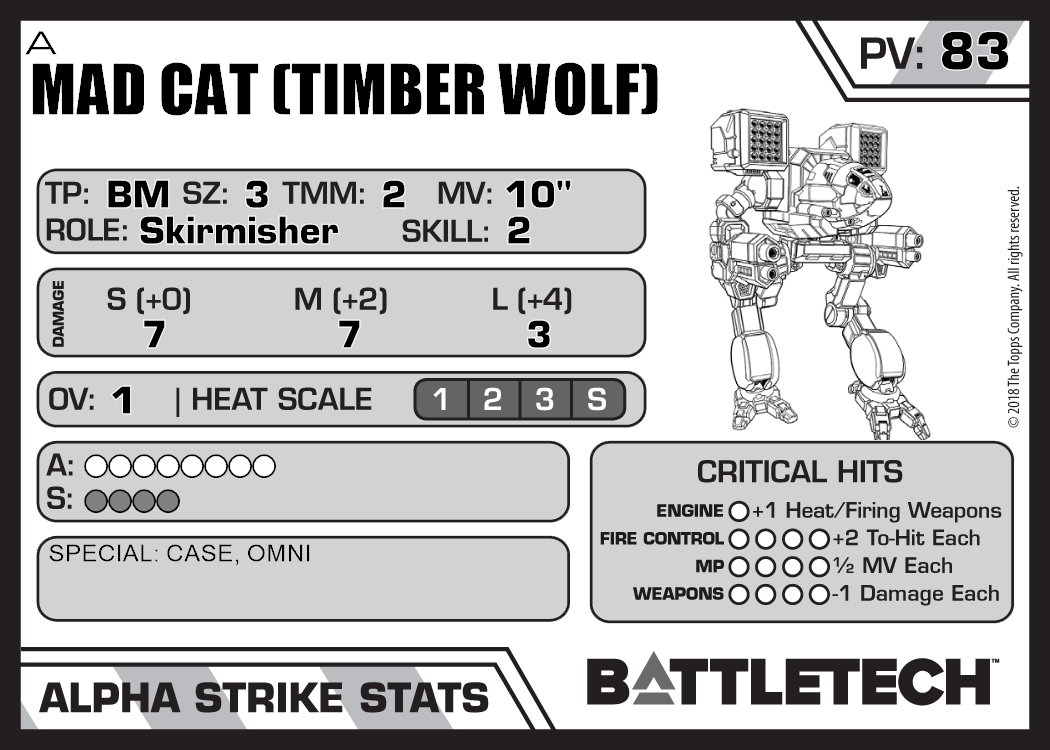

ID 1978 REPEAT: units_cards/card_1978.png
URL: http://masterunitlist.info/Unit/Card/2066?skill=2
SAVED: units_cards/card_2066.png


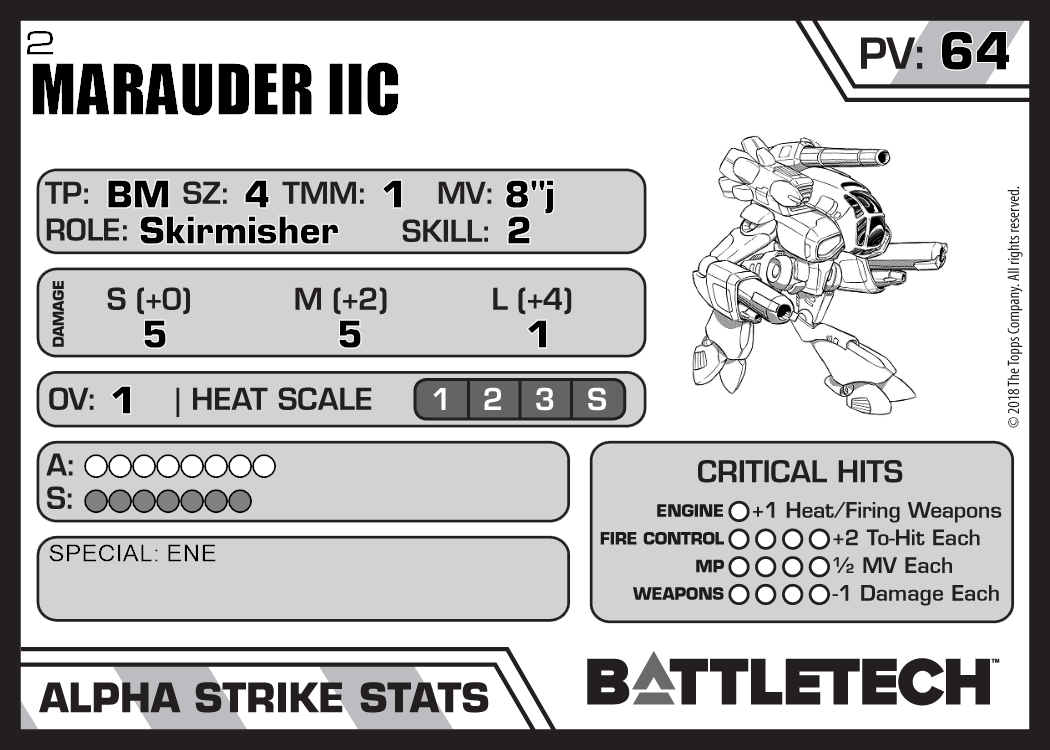

URL: http://masterunitlist.info/Unit/Card/284?skill=1
SAVED: units_cards/card_284.png


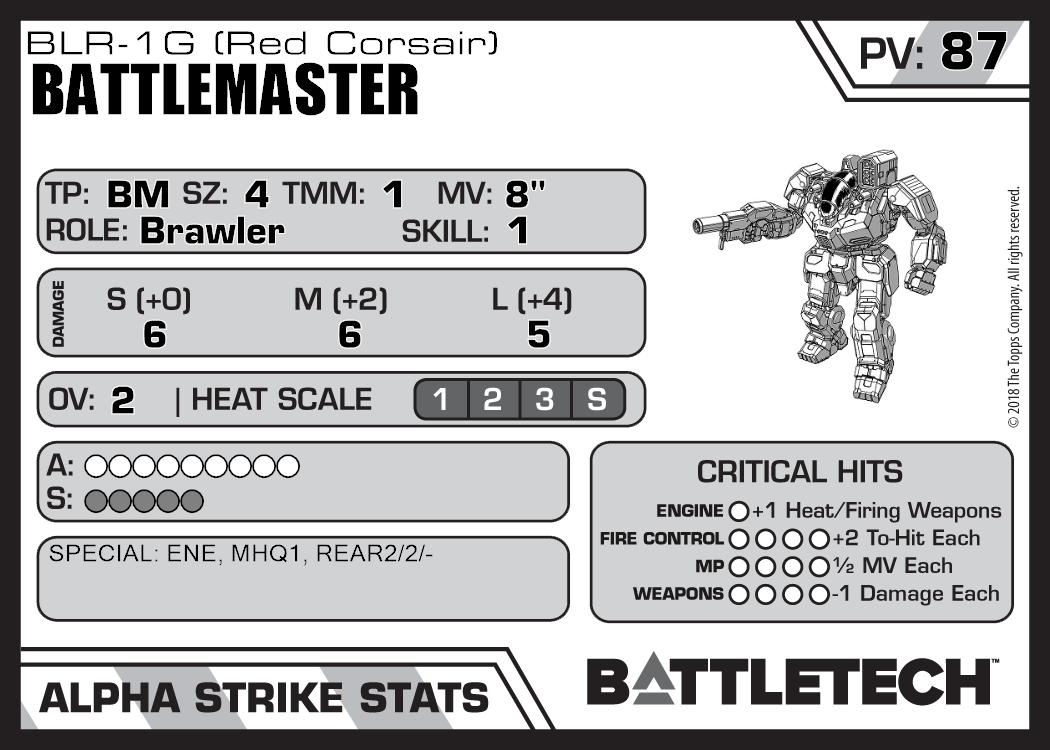

URL: http://masterunitlist.info/Unit/Card/1923?skill=2
SAVED: units_cards/card_1923.png


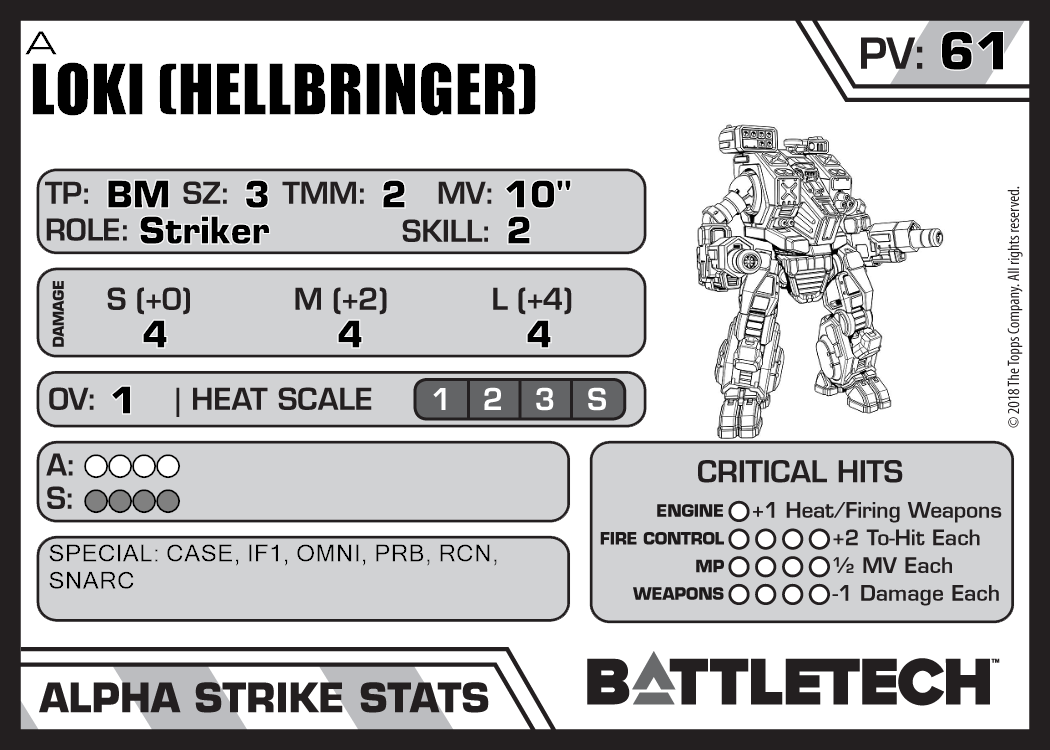

URL: http://masterunitlist.info/Unit/Card/1333?skill=2
SAVED: units_cards/card_1333.png


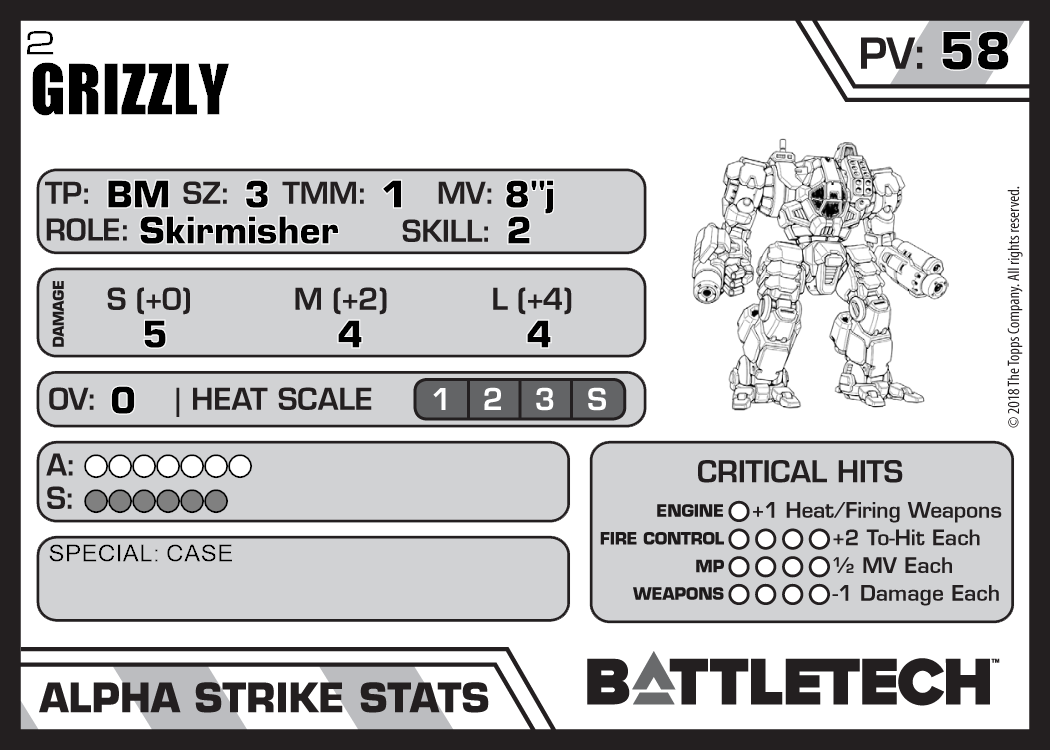

URL: http://masterunitlist.info/Unit/Card/3346?skill=2
SAVED: units_cards/card_3346.png


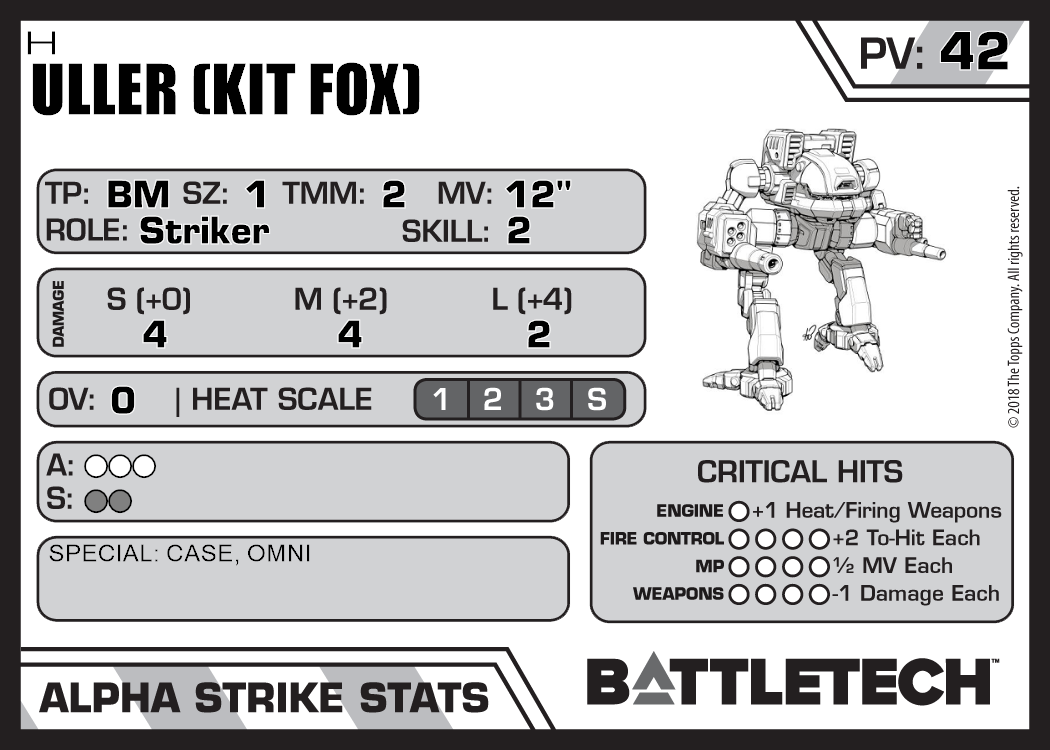

URL: http://masterunitlist.info/Unit/Card/2560?skill=1
SAVED: units_cards/card_2560.png


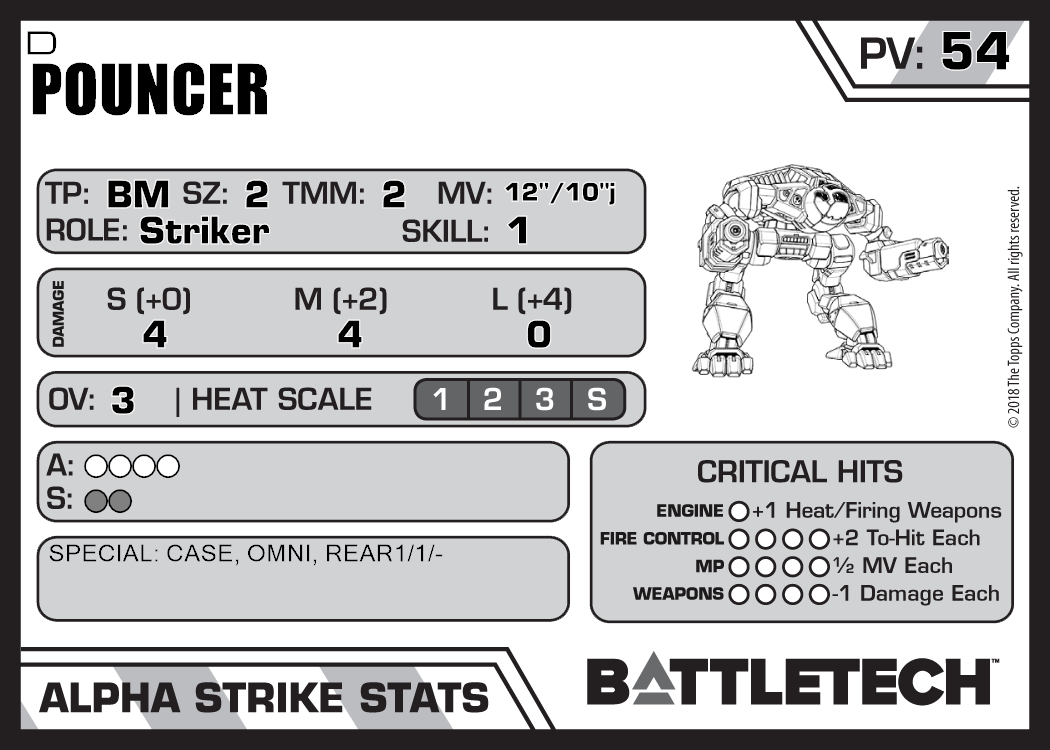

URL: http://masterunitlist.info/Unit/Card/2753?skill=1
SAVED: units_cards/card_2753.png


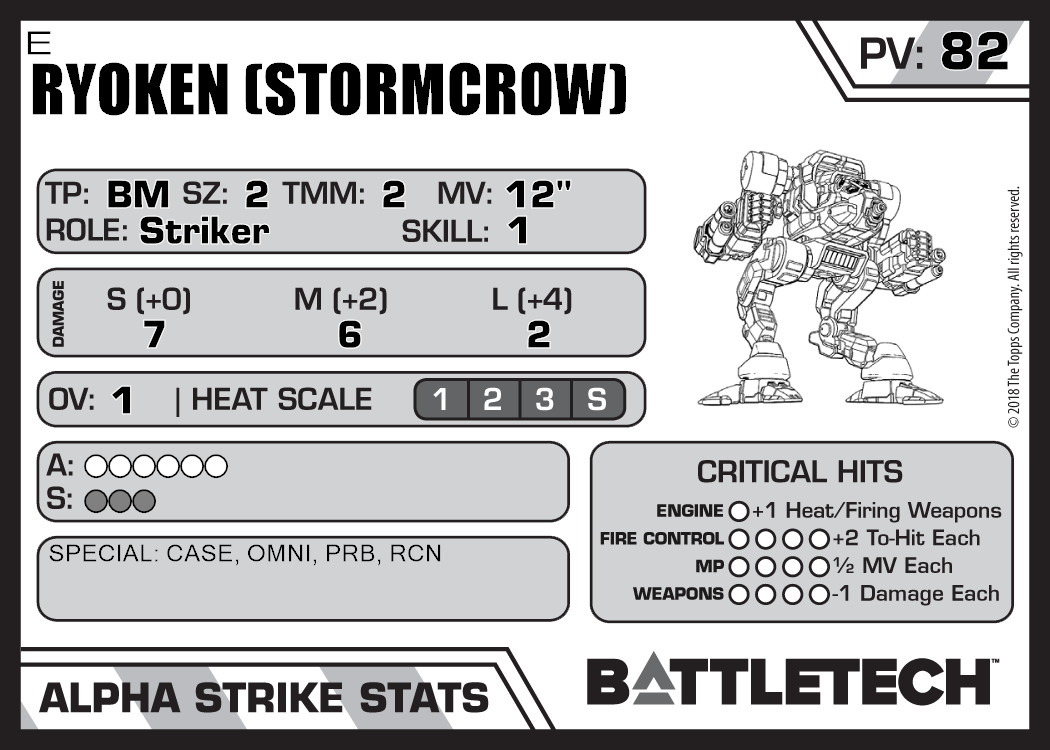

URL: http://masterunitlist.info/Unit/Card/1834?skill=2
SAVED: units_cards/card_1834.png


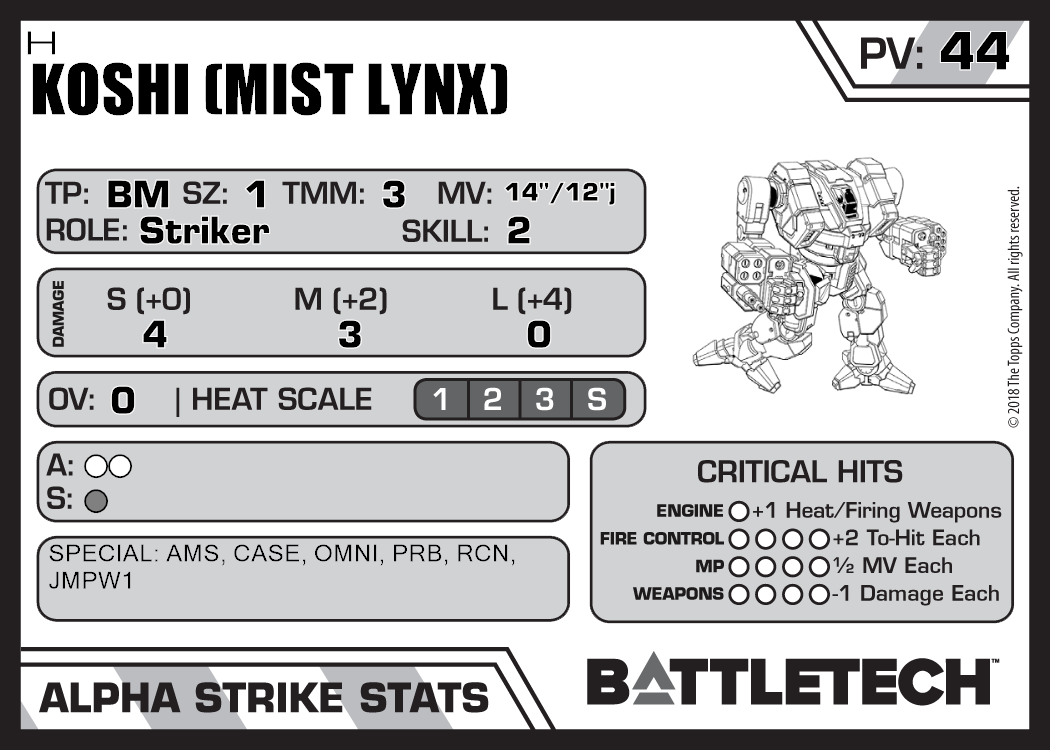

URL: http://masterunitlist.info/Unit/Card/841?skill=2
SAVED: units_cards/card_841.png


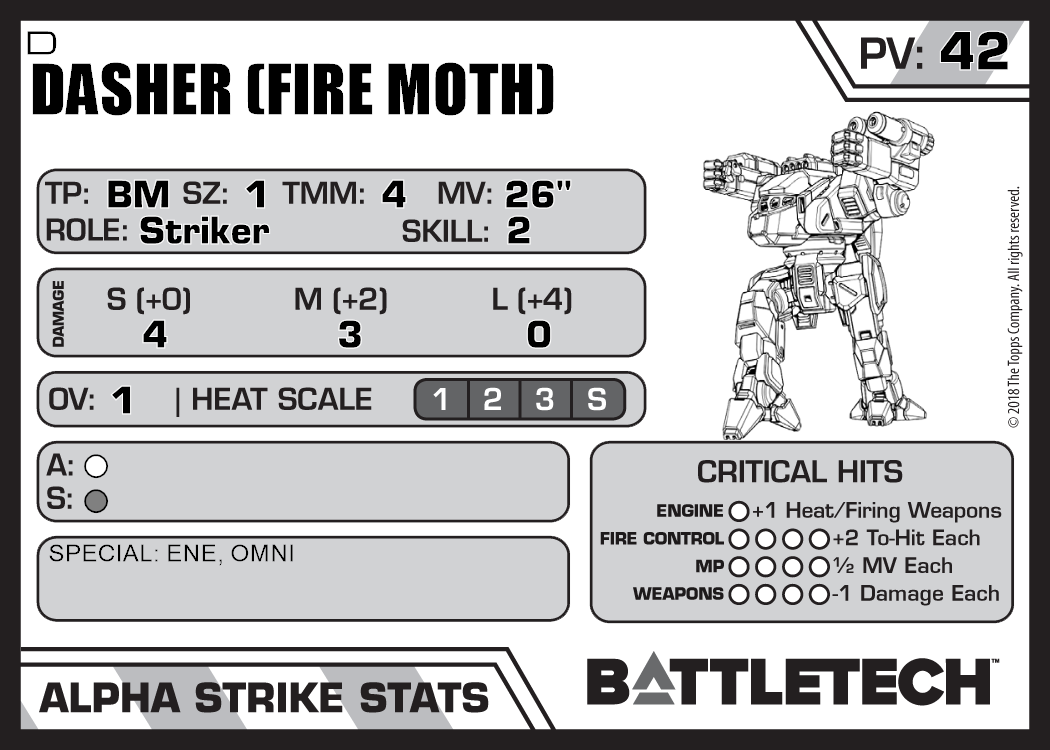

Игрок 2
URL: http://masterunitlist.info/Unit/Card/8275?skill=0
SAVED: units_cards/card_8275.png


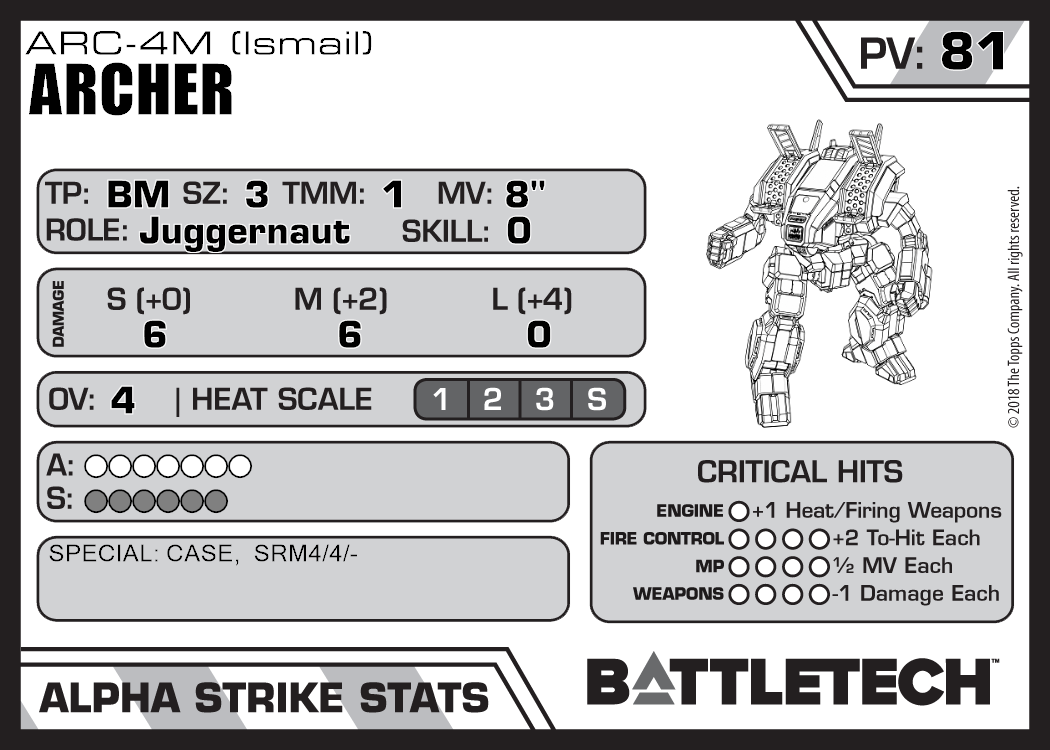

URL: http://masterunitlist.info/Unit/Card/7618?skill=2
SAVED: units_cards/card_7618.png


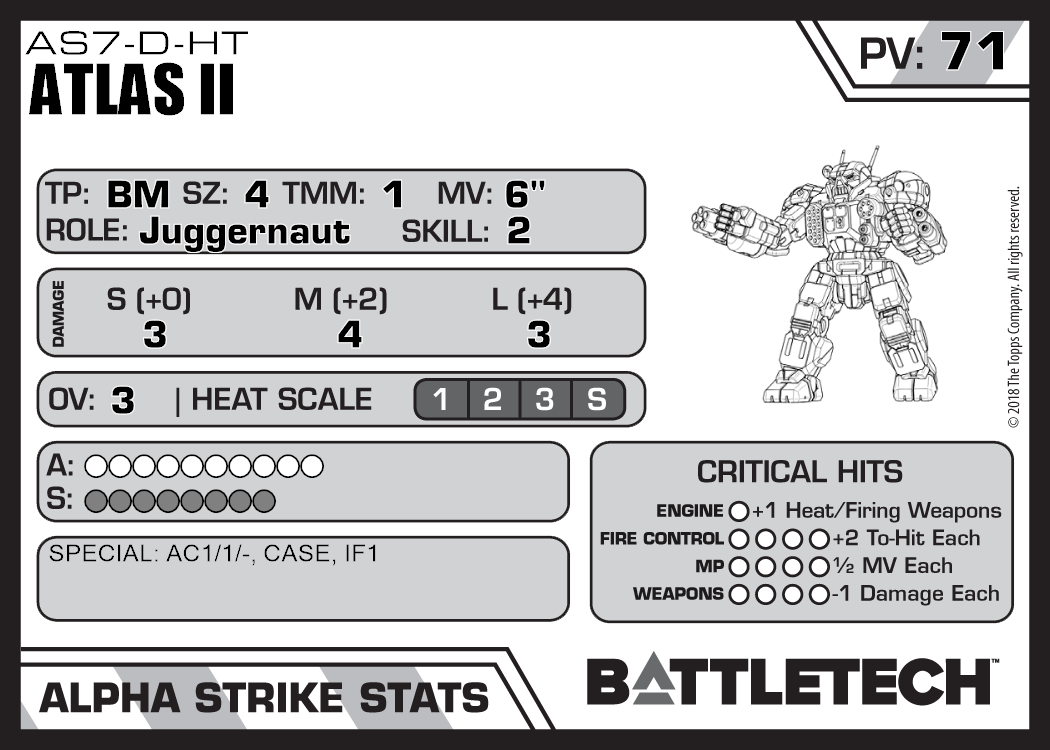

ID 7618 REPEAT: units_cards/card_7618.png
URL: http://masterunitlist.info/Unit/Card/893?skill=2
SAVED: units_cards/card_893.png


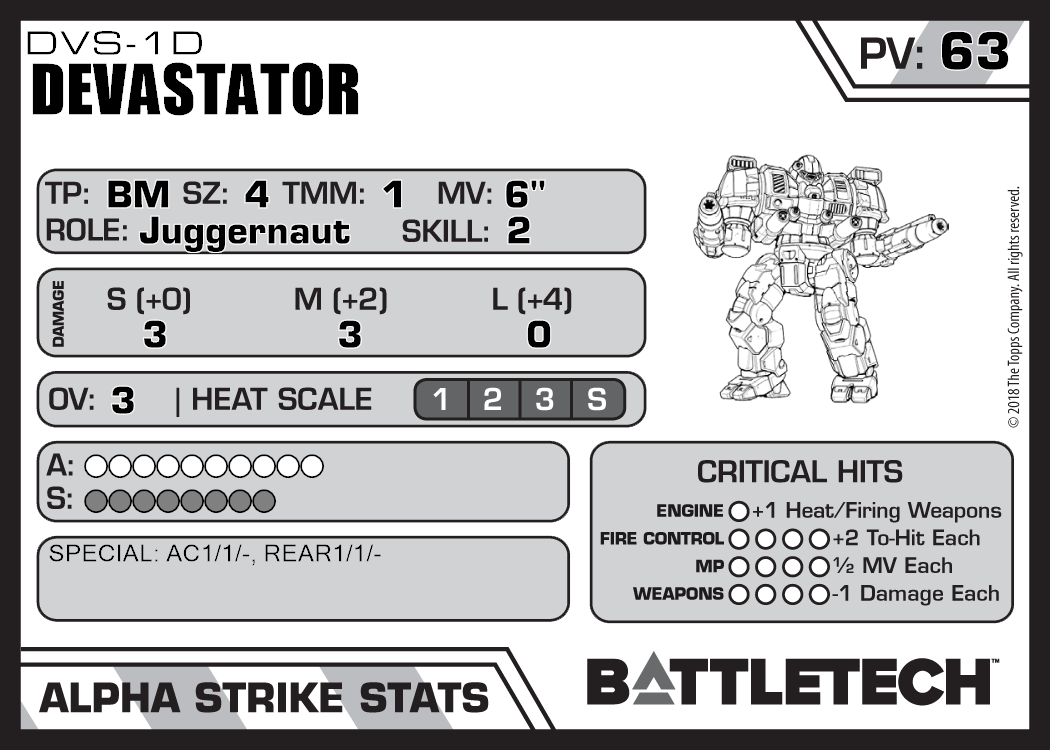

URL: http://masterunitlist.info/Unit/Card/8282?skill=0
SAVED: units_cards/card_8282.png


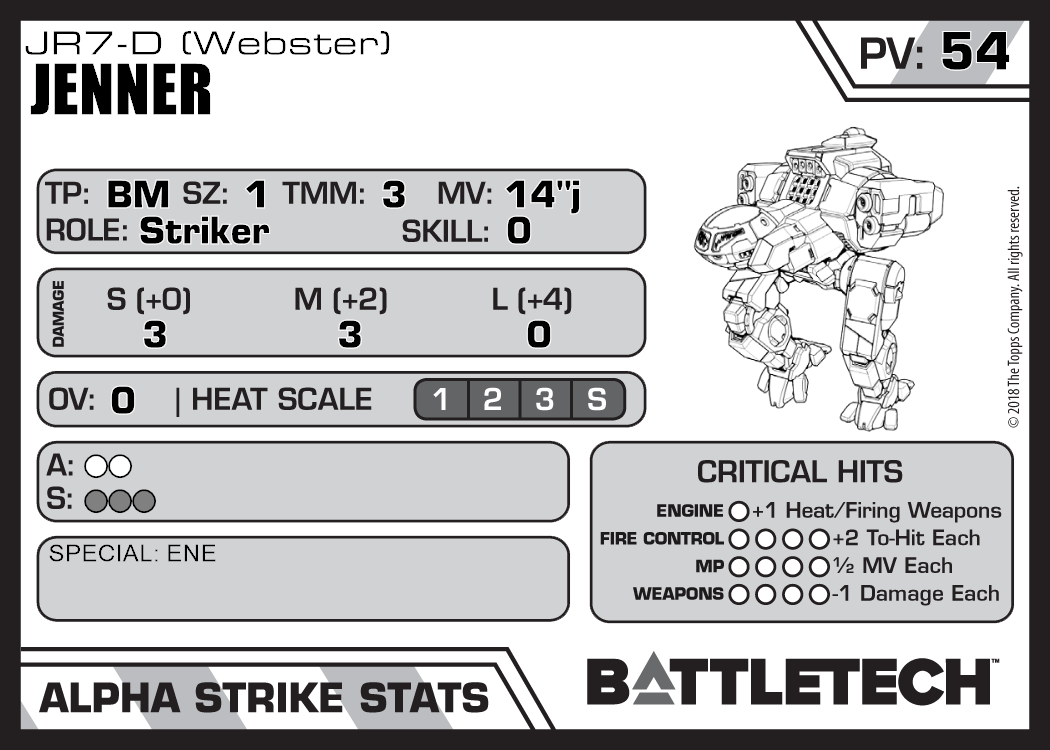

URL: http://masterunitlist.info/Unit/Card/3588?skill=4
SAVED: units_cards/card_3588.png


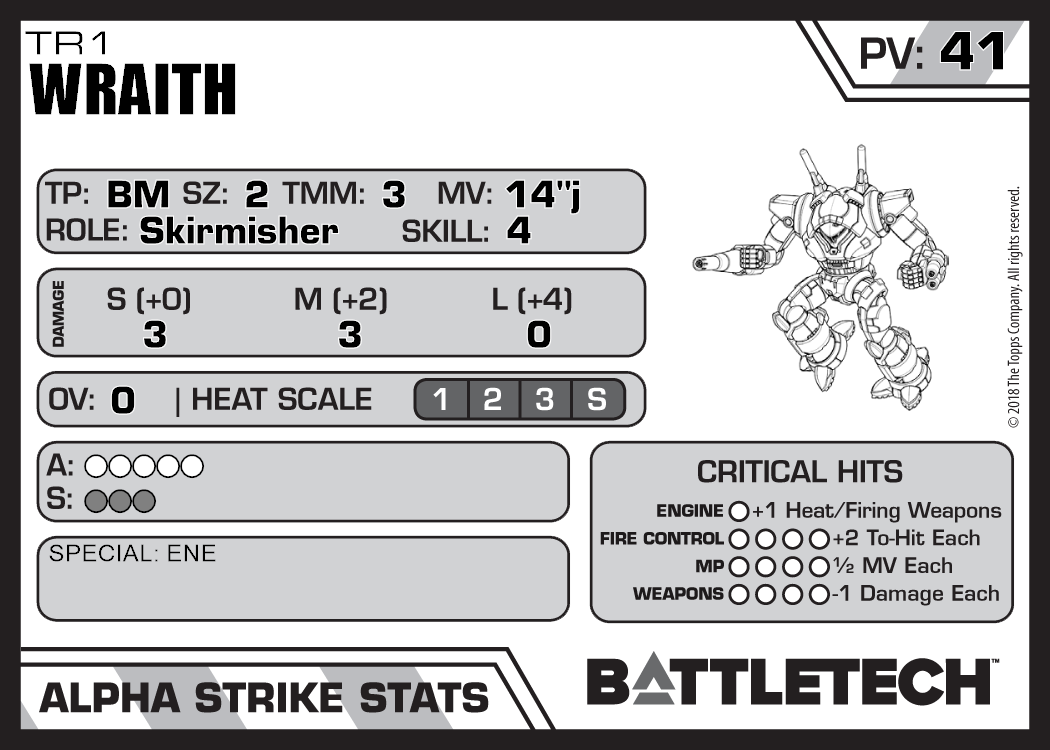

URL: http://masterunitlist.info/Unit/Card/7321?skill=4
SAVED: units_cards/card_7321.png


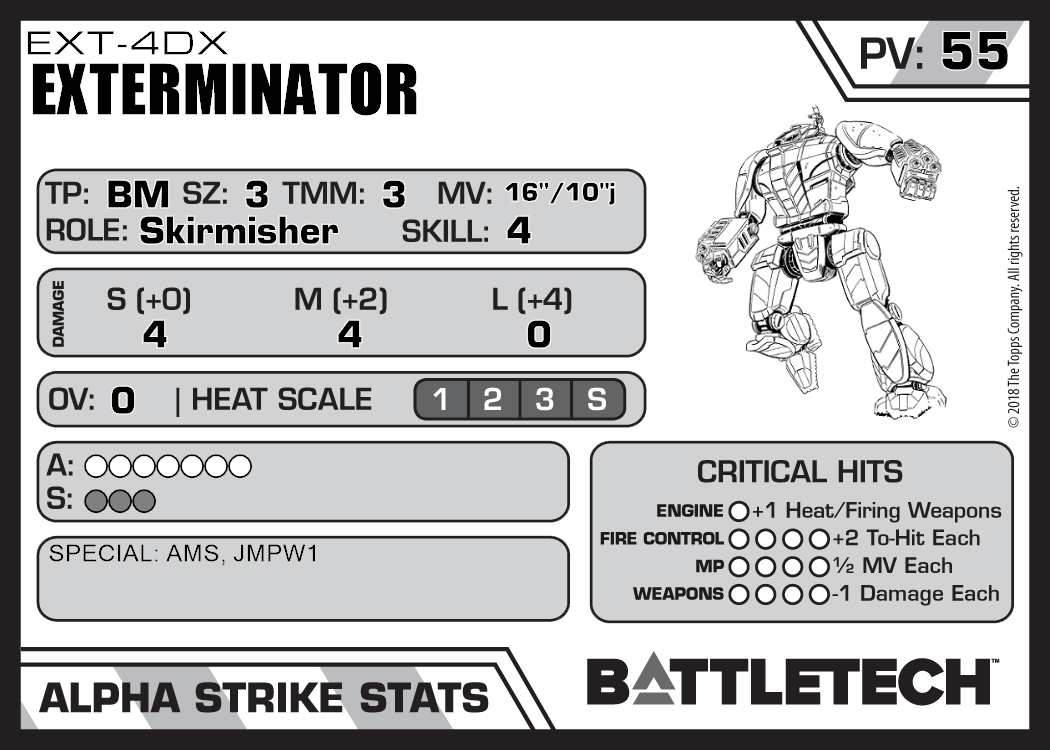

URL: http://masterunitlist.info/Unit/Card/2502?skill=4
SAVED: units_cards/card_2502.png


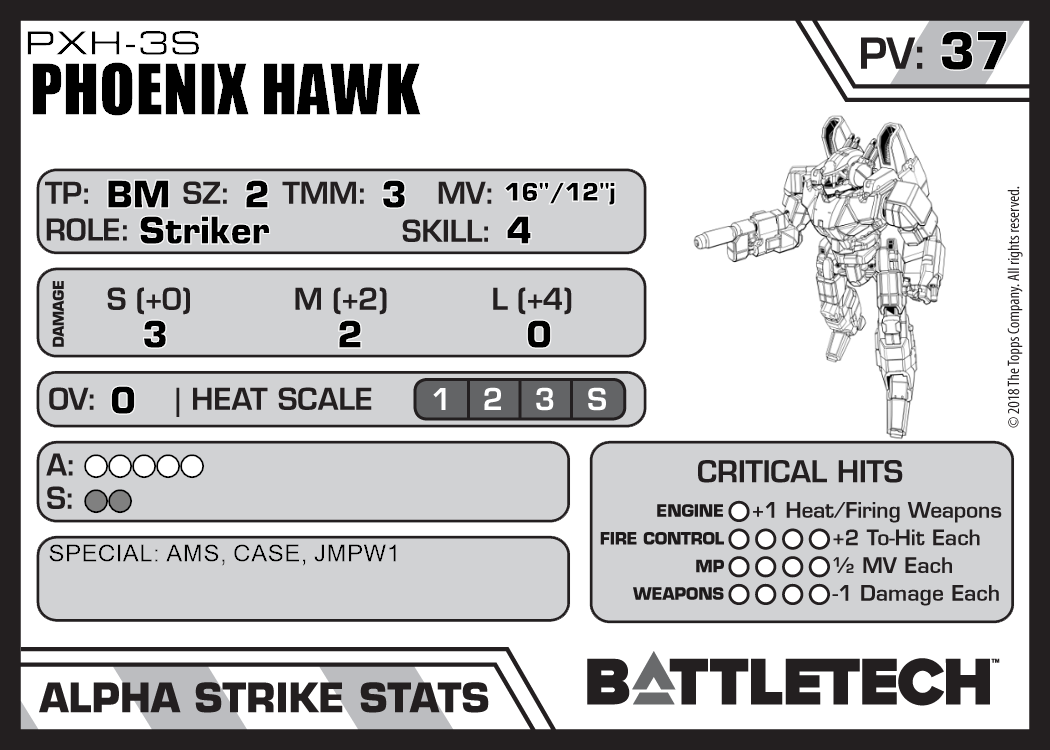

URL: http://masterunitlist.info/Unit/Card/2115?skill=4
SAVED: units_cards/card_2115.png


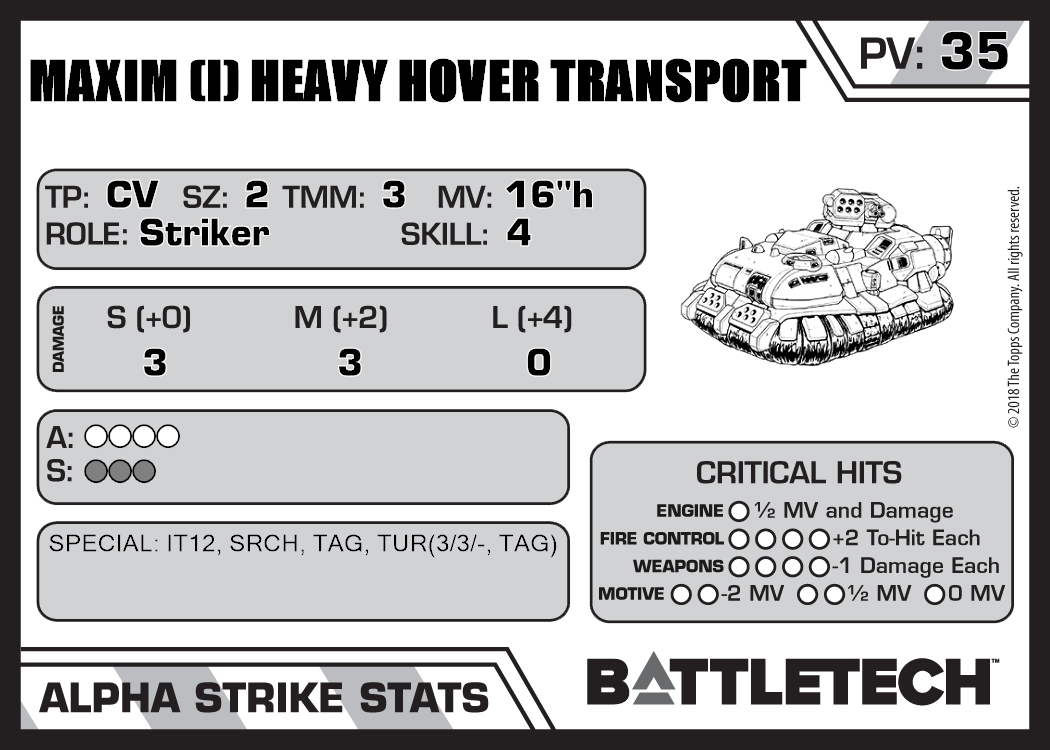

URL: http://masterunitlist.info/Unit/Card/1628?skill=4
SAVED: units_cards/card_1628.png


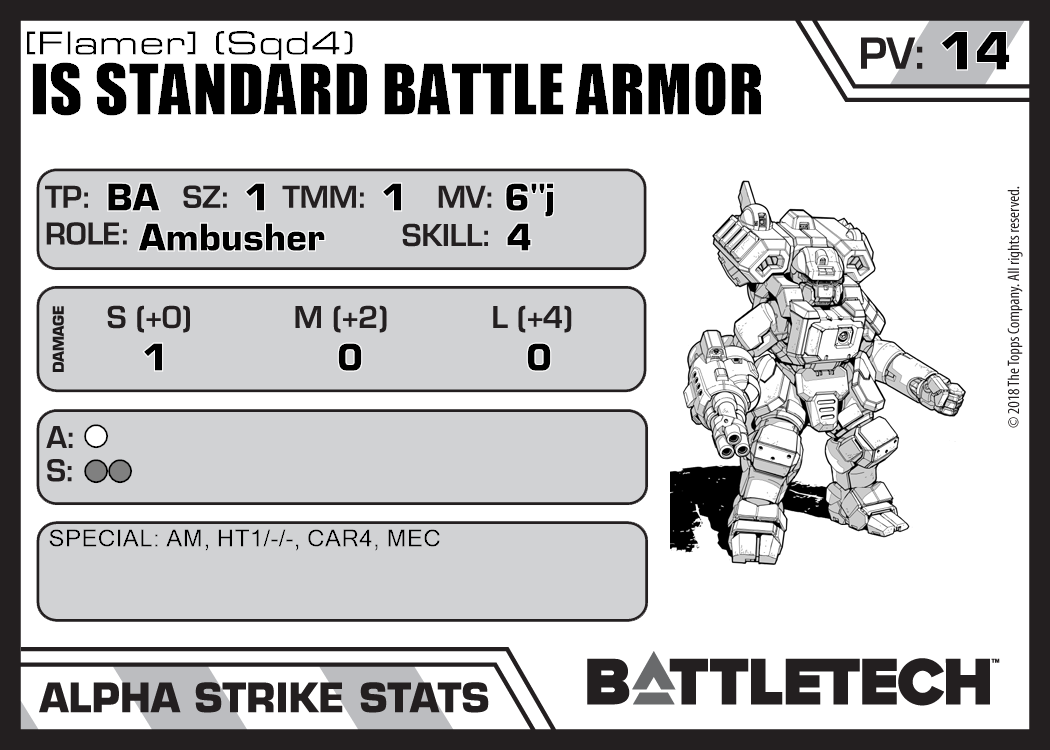

ID 1628 REPEAT: units_cards/card_1628.png
ID 1628 REPEAT: units_cards/card_1628.png
ID 2115 REPEAT: units_cards/card_2115.png
ID 1628 REPEAT: units_cards/card_1628.png
ID 1628 REPEAT: units_cards/card_1628.png
ID 1628 REPEAT: units_cards/card_1628.png
Игрок 3
URL: http://masterunitlist.info/Unit/Card/22?skill=4
SAVED: units_cards/card_22.png


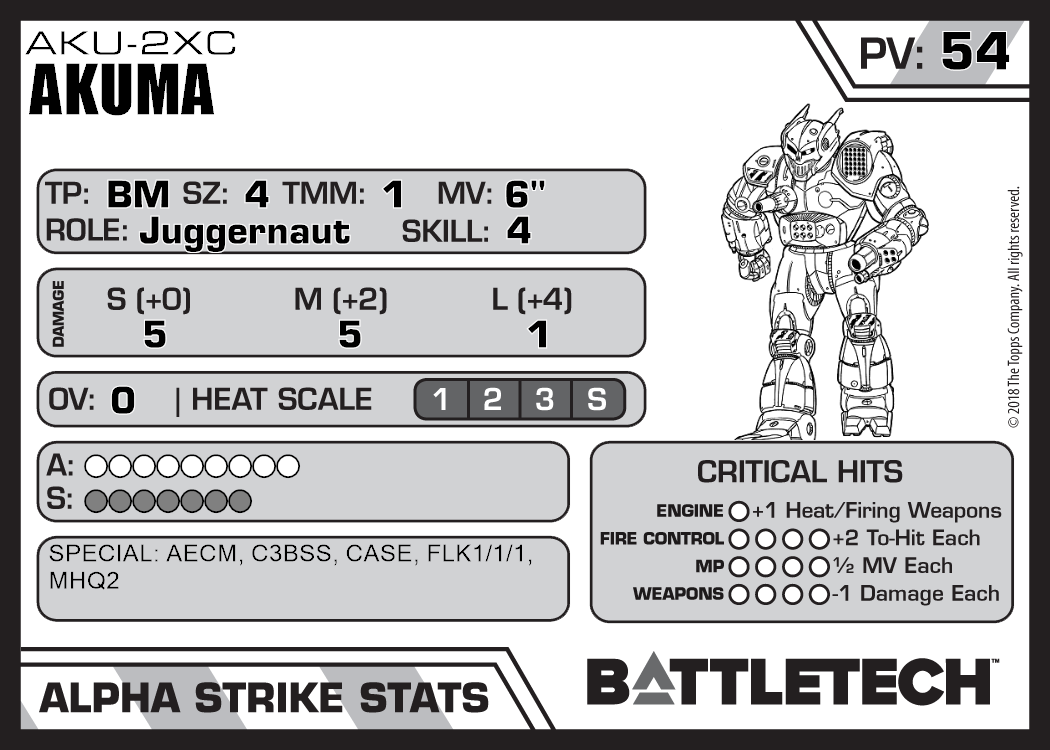

ID 22 REPEAT: units_cards/card_22.png
Игрок 4
URL: http://masterunitlist.info/Unit/Card/7309?skill=4
SAVED: units_cards/card_7309.png


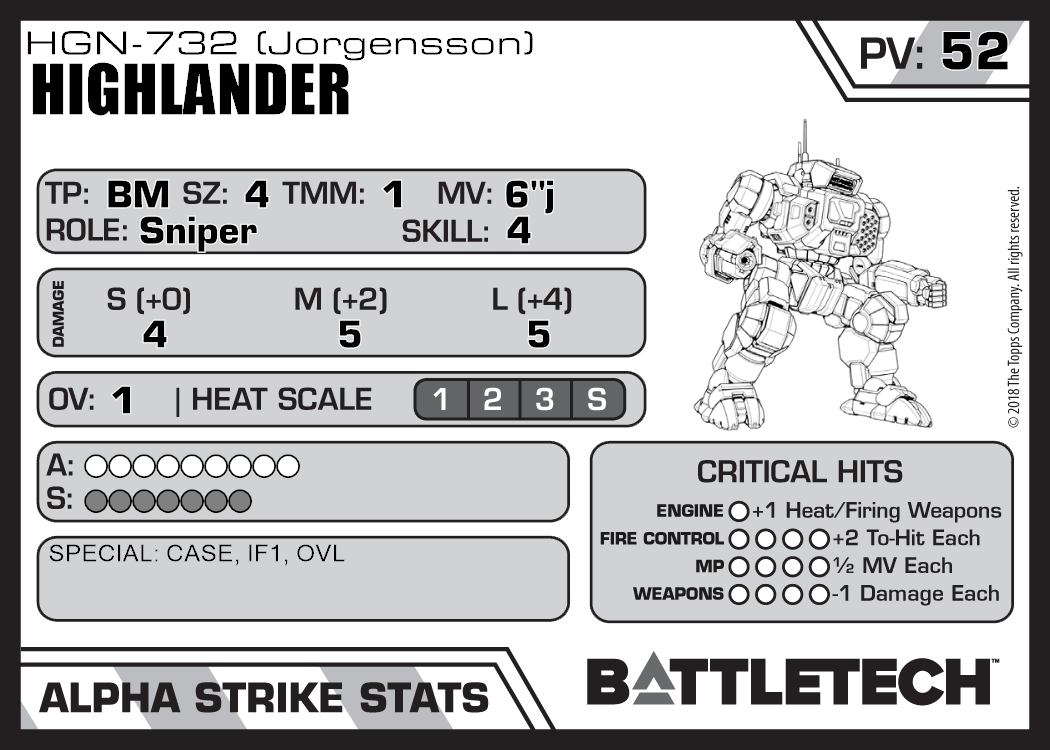

URL: http://masterunitlist.info/Unit/Card/6448?skill=4
SAVED: units_cards/card_6448.png


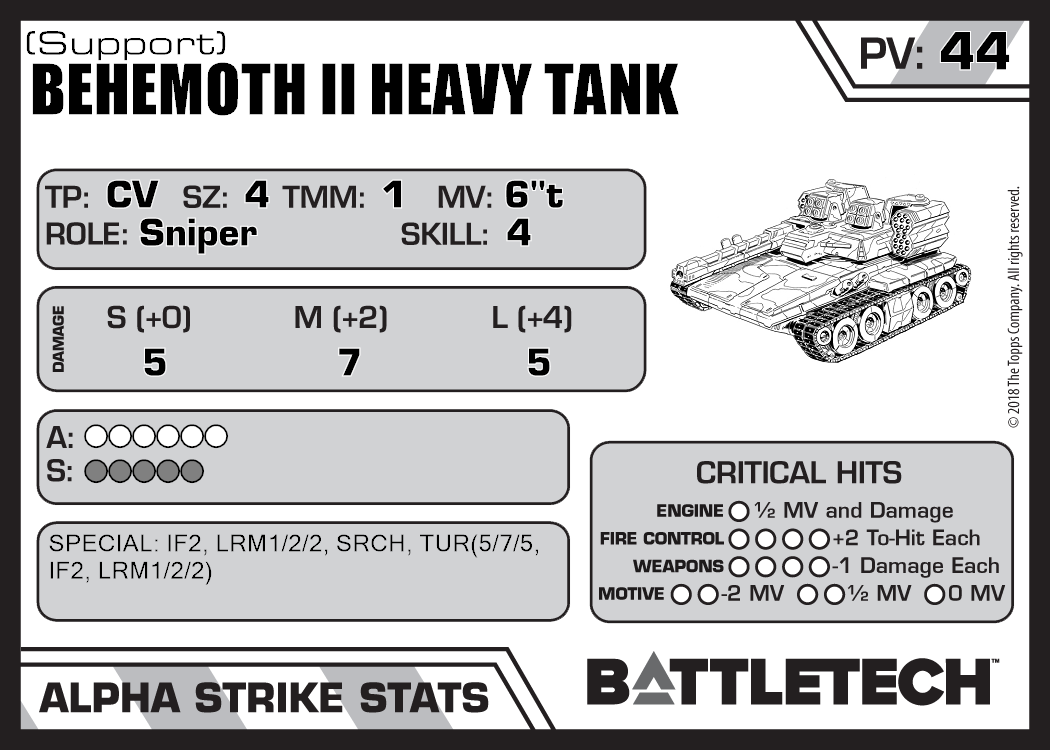

CARDS: 31


In [46]:
# @title
folder_name = "units_cards"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

base_card_url = "http://masterunitlist.info/Unit/Card/"

images_paths = []
cache_ids = {}

for i, unit_id in enumerate(unit_ids):

    if "Игрок" in str(unit_id):
      print(unit_id)
      continue

    if unit_id in cache_ids:
        images_paths.append(cache_ids[unit_id])
        print(f"ID {unit_id} REPEAT: {cache_ids[unit_id]}")
        continue

    file_path = os.path.join(folder_name, f"card_{unit_id}.png")
    img_url = f"{base_card_url}{unit_id}?skill={skills[i]}"

    try:
        response = requests.get(img_url, stream=True)
        response.raise_for_status()

        if "image" in response.headers.get("Content-Type", ""):

            with open(file_path, "wb") as f:
                f.write(response.content)

            images_paths.append(file_path)
            cache_ids[unit_id] = file_path
            print(f"URL: {img_url}")
            print(f"SAVED: {file_path}")

            display(Image(file_path, width=400))
        else:
            print(f"ID {unit_id}: IMAGE NOT FOUND")

    except Exception as e:
        print(f"ERROR {unit_id}: {e}")

    time.sleep(0.1)

print(f"CARDS: {len(images_paths)}")

Save PDF (FILE BUTTON ON THE LEFT PANNEL)

In [47]:
# @title
def create_as_pdf(unit_ids, output_filename=None):
    if output_filename is None:
        output_filename = f"AlphaStrike Force {datetime.today().strftime('%Y-%m-%d')}.pdf"

    pdf = FPDF(orientation='P', unit='mm', format='A4')
    pdf.add_page()

    pdf.set_font("Helvetica", style="B", size=16)

    card_w = 95
    card_h = 68
    margin_left = ОТСТУП_СЛЕВА
    margin_top = ОТСТУП_СВЕРХУ
    spacing_x = 1
    spacing_y = 1

    current_x = margin_left
    current_y = margin_top

    for unit_id in unit_ids:
        u_id_str = str(unit_id)

        if "Игрок" in u_id_str or "Player" in u_id_str:
            if current_x > margin_left:
                current_y += card_h + spacing_y
                current_x = margin_left

            if current_y + 15 + card_h > 280:
                pdf.add_page()
                current_y = margin_top

            display_text = u_id_str.upper().replace("ИГРОК", "PLAYER")

            pdf.set_xy(margin_left, current_y)
            pdf.set_font("Helvetica", "B", 12)
            pdf.cell(card_w * 2, 6, text=display_text, align='L', new_x="LMARGIN", new_y="NEXT")

            current_y = pdf.get_y() + 2
            current_x = margin_left
            continue

        if current_y + card_h > 295:
            pdf.add_page()
            current_y = margin_top
            current_x = margin_left

        img_path = f"units_cards/card_{u_id_str}.png"

        if os.path.exists(img_path):
            pdf.image(img_path, x=current_x, y=current_y, w=card_w, h=card_h)
        else:
            pdf.set_draw_color(200)
            pdf.rect(current_x, current_y, card_w, card_h)
            pdf.set_font("Helvetica", "", 10)
            pdf.set_xy(current_x, current_y + (card_h/2))
            pdf.cell(card_w, 10, text=f"MISSING: {u_id_str}", align='C')

        pdf.set_draw_color(0)
        pdf.rect(current_x, current_y, card_w, card_h)

        if current_x == margin_left:
            current_x = margin_left + card_w + spacing_x
        else:
            current_x = margin_left
            current_y += card_h + spacing_y

    pdf.output(output_filename)
    print(f"PDF SAVED: {output_filename}")

create_as_pdf(unit_ids)

PDF SAVED: AlphaStrike Force 2026-04-24.pdf
